# Concentration Regression

Estimates sugar-water concentration from polarimetric features
using linear regression on the polarization angle.

Demonstrates that PolySight can distinguish fine-grained
concentration differences in liquid mixtures.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pickle

from sklearn.linear_model import LinearRegression

%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')
from polysight.eval import polarimetry as pol
from polysight.eval import permittivity as fresnel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
labels_dir = '../data/labels/'
materials_dir = '../data/materials/'

## Load labeled material datasets

In [4]:
pol_config = {'AR': 0.05, 'percentile_range': [30, 70]}

permittivity_list = []
for file_path in sorted(glob.glob(os.path.join(materials_dir, 'water*_55.pkl'))):
    with open(file_path, 'rb') as f:
        mat = pickle.load(f)

    theta, angle_refed = pol.calc_polarimetry(
        mat['values'][2], mat['ref_values'][2], config=pol_config)
    pol_val = np.tan(np.deg2rad(theta))
    eps = fresnel.ratio_to_epsilon(pol_val, mat['incident_angle'])
    eps_complex = fresnel.ratio_to_epsilon(
        pol_val * np.exp(-1j * np.angle(angle_refed)), mat['incident_angle'])

    permittivity_list.append({
        'name': mat['name'] + '_55',
        'permittivity': eps,
        'permittivity_complex': eps_complex,
        'pol_angle': theta,
        'div_val': angle_refed,
    })

    mean_eps = fresnel.ratio_to_epsilon(
        np.tan(np.mean(np.deg2rad(theta))), mat['incident_angle'])
    print(f'{mat["name"]:<25s} eps = {mean_eps:.2f}')

water                     eps = 3.75
water_sugar_1sp           eps = 3.81
water_sugar_2sp           eps = 4.00
water_sugar_3sp           eps = 3.87
water_sugar_4sp           eps = 3.89
water_sugar_5sp           eps = 3.96
water_sugar_6sp           eps = 4.02


## Select concentration series

In [5]:
# Sugar-water concentrations (by weight)
show_list = {
    'water_55':           '0%',
    'water_sugar_1sp_55': '1.3%',
    'water_sugar_3sp_55': '3.8%',
    'water_sugar_4sp_55': '5.1%',
    'water_sugar_5sp_55': '6.3%',
    'water_sugar_6sp_55': '7.4%',
}

filtered = [x for key in show_list for x in permittivity_list if x['name'] == key]
conc_labels = [show_list[x['name']] for x in filtered]
pol_angles = [x['pol_angle'] for x in filtered]
div_angles = [np.angle(x['div_val']) for x in filtered]
eps_complex = [x['permittivity_complex'] for x in filtered]

## Permittivity box plots

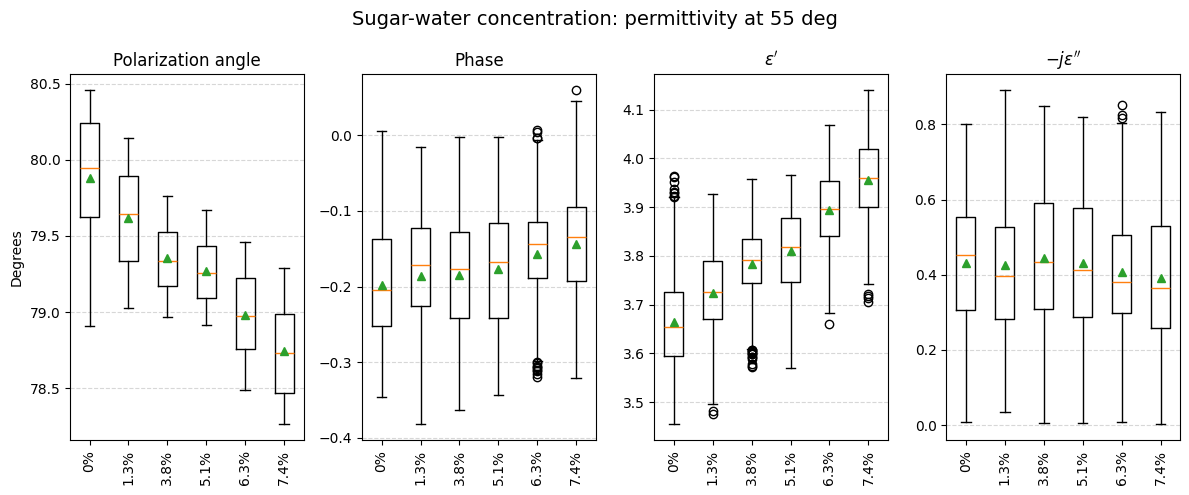

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5))

axes[0].boxplot([x.ravel() for x in pol_angles], showmeans=True)
axes[0].set_title('Polarization angle')
axes[0].set_ylabel('Degrees')
axes[0].set_xticks(range(1, len(conc_labels) + 1), conc_labels)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=90)

axes[1].boxplot([x.ravel() for x in div_angles], showmeans=True)
axes[1].set_title('Phase')
axes[1].set_xticks(range(1, len(conc_labels) + 1), conc_labels)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=90)

axes[2].boxplot([x.real.ravel() for x in eps_complex], showmeans=True)
axes[2].set_title(r"$\epsilon'$")
axes[2].set_xticks(range(1, len(conc_labels) + 1), conc_labels)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=90)

axes[3].boxplot([np.abs(x.imag).ravel() for x in eps_complex], showmeans=True)
axes[3].set_title(r"$-j\epsilon''$")
axes[3].set_xticks(range(1, len(conc_labels) + 1), conc_labels)
axes[3].grid(True, axis='y', linestyle='--', alpha=0.5)
axes[3].tick_params(axis='x', rotation=90)

fig.suptitle('Sugar-water concentration: permittivity at 55 deg', fontsize=14)
plt.tight_layout()
plt.show()

## Linear regression: concentration estimation

Slope: -393.0989, Intercept: 548.1038


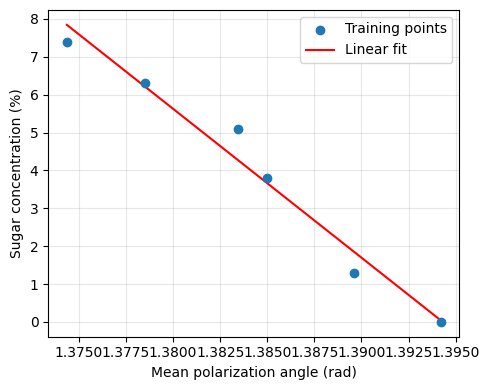

In [7]:
# Train: mean polarization angle -> concentration
x_train = np.array([np.mean(np.deg2rad(a)) for a in pol_angles]).reshape(-1, 1)
y_train = np.array([0, 1.3, 3.8, 5.1, 6.3, 7.4])

model = LinearRegression()
model.fit(x_train, y_train)
print(f'Slope: {model.coef_[0]:.4f}, Intercept: {model.intercept_:.4f}')

# Plot fit
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_train, y_train, zorder=5, label='Training points')
x_plot = np.linspace(x_train.min(), x_train.max(), 50).reshape(-1, 1)
ax.plot(x_plot, model.predict(x_plot), 'r-', label='Linear fit')
ax.set_xlabel('Mean polarization angle (rad)')
ax.set_ylabel('Sugar concentration (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-pixel concentration error CDF

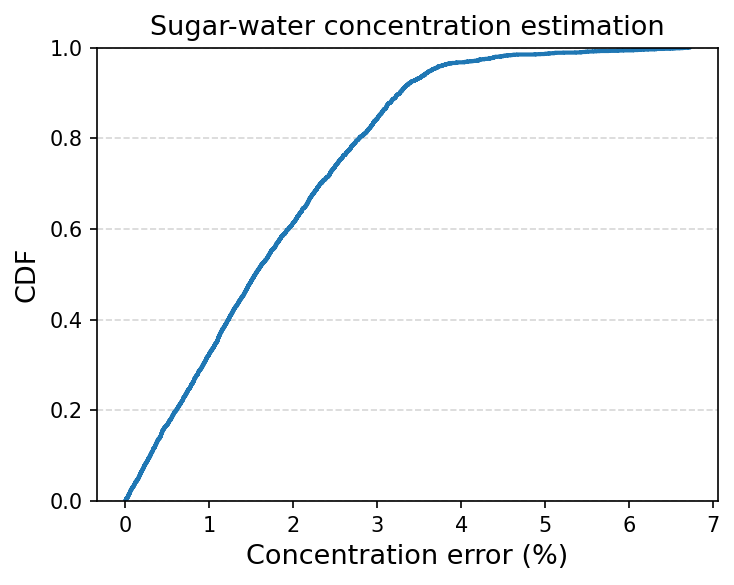

Median error: 1.55%


In [8]:
errors = []
for i, angles in enumerate(pol_angles):
    x_test = np.deg2rad(angles).reshape(-1, 1)
    y_pred = model.predict(x_test)
    errors.append(np.abs(y_pred - y_train[i]))

all_errors = np.concatenate(errors)

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
ax.ecdf(all_errors, lw=2)
ax.set_ylabel('CDF', fontsize=13)
ax.set_xlabel('Concentration error (%)', fontsize=13)
ax.set_title('Sugar-water concentration estimation', fontsize=13)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Median error: {np.median(all_errors):.2f}%')